<a href="https://colab.research.google.com/github/marwaashfaq2004-ai/RL/blob/main/Q_learning_Algorithm_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip uninstall -y gym # Explicitly uninstall the old gym library
!pip install gymnasium
!pip install matplotlib
# We will let gymnasium handle numpy compatibility, so no explicit numpy install here.

Found existing installation: gym 0.25.2
Uninstalling gym-0.25.2:
  Successfully uninstalled gym-0.25.2


In [49]:
import gymnasium
import numpy as np
import matplotlib.pyplot as plt
import pickle
from numpy.linalg import svd

In [31]:
env = gymnasium.make("MountainCar-v0", render_mode='rgb_array') # Set render_mode here
DISCRETE_OS_SIZE = [20] * len(env.observation_space.high)
discrete_os_win_size = (env.observation_space.high - env.observation_space.low) / DISCRETE_OS_SIZE

In [6]:
LEARNING_RATE = 0.1
DISCOUNT = 0.95
# EPISODES = 150
# SHOW_EVERY = 10
EPISODES = 2000
SHOW_EVERY = 2000
epsilon = 0.5
START_EPSILON_DECAYING = 1
END_EPSILON_DECAYING = EPISODES // 2
epsilon_decay_value = epsilon / (END_EPSILON_DECAYING - START_EPSILON_DECAYING)

In [7]:
ep_rewards = []
aggr_ep_rewards = {'ep': [], 'avg': [], 'min': [], 'max': []}


In [8]:
q_table = np.random.uniform(low=-2, high=0, size=(DISCRETE_OS_SIZE + [env.action_space.n]))

def get_discrete_state(state):
    discrete_state = (state - env.observation_space.low) / discrete_os_win_size
    discrete_state = np.clip(discrete_state, 0, np.array(DISCRETE_OS_SIZE) - 1)
    return tuple(discrete_state.astype(np.int32))

# Track highest position and frame
highest_position = -float('inf')
highest_frame = None

In [58]:
for episode in range(EPISODES):
    episode_reward = 0
    discrete_state = get_discrete_state(env.reset()[0])
    done = False # Initialize done for the outer loop

    while not done:
        # Epsilon-greedy action
        if np.random.random() > epsilon:
            action = np.argmax(q_table[discrete_state])
        else:
            action = np.random.randint(0, env.action_space.n)

        new_state, reward, terminated, truncated, info = env.step(action) # Unpack 5 values
        done = terminated or truncated # Combine terminated and truncated into done
        new_discrete_state = get_discrete_state(new_state)

        # Track highest position and save rendered frame
        if new_state[0] > highest_position:
            highest_position = new_state[0]
            highest_frame = env.render() # Removed mode argument

        if not done:
            # Q-learning update rule
            max_future_q = np.max(q_table[new_discrete_state])
            current_q = q_table[discrete_state + (action,)]
            new_q = (1 - LEARNING_RATE) * current_q + LEARNING_RATE * (reward + DISCOUNT * max_future_q)
            q_table[discrete_state + (action,)] = new_q
        elif new_state[0] >= env.unwrapped.goal_position: # Access goal_position via env.unwrapped
            # Reached the flag!
            q_table[discrete_state + (action,)] = 0

        discrete_state = new_discrete_state
        episode_reward += reward

    # Decay epsilon
    if END_EPSILON_DECAYING >= episode >= START_EPSILON_DECAYING:
        epsilon -= epsilon_decay_value

    ep_rewards.append(episode_reward)

    # Move reward aggregation logic here
    if episode % SHOW_EVERY == 0:
        avg_reward = sum(ep_rewards[-SHOW_EVERY:]) / SHOW_EVERY
        aggr_ep_rewards['ep'].append(episode)
        aggr_ep_rewards['avg'].append(avg_reward)
        aggr_ep_rewards['min'].append(min(ep_rewards[-SHOW_EVERY:]))
        aggr_ep_rewards['max'].append(max(ep_rewards[-SHOW_EVERY:]))
        print(f"Episode: {episode}, avg: {avg_reward:.2f}, min: {min(ep_rewards[-SHOW_EVERY:])}, max: {max(ep_rewards[-SHOW_EVERY:])}")

    # Move SVD application logic here
    if episode % SVD_EVERY == 0 and episode != 0:
        print(f"Applying SVD compression at episode {episode}")
        for a in range(env.action_space.n):
            q_slice = q_table[:, :, a]
            U, S, Vt = svd(q_slice, full_matrices=False)
            S[SVD_RANK:] = 0  # Keep top-k singular values
            q_table[:, :, a] = np.dot(U * S, Vt)
            print("size is")
            print(q_table.size)

Episode: 0, avg: -171.70, min: -200.0, max: -144.0
Applying SVD compression at episode 5
size is
1200
size is
1200
size is
1200
Episode: 10, avg: -153.00, min: -200.0, max: -121.0
Applying SVD compression at episode 10
size is
1200
size is
1200
size is
1200
Applying SVD compression at episode 15
size is
1200
size is
1200
size is
1200
Episode: 20, avg: -159.10, min: -169.0, max: -147.0
Applying SVD compression at episode 20
size is
1200
size is
1200
size is
1200
Applying SVD compression at episode 25
size is
1200
size is
1200
size is
1200
Episode: 30, avg: -164.60, min: -200.0, max: -117.0
Applying SVD compression at episode 30
size is
1200
size is
1200
size is
1200
Applying SVD compression at episode 35
size is
1200
size is
1200
size is
1200
Episode: 40, avg: -161.20, min: -200.0, max: -128.0
Applying SVD compression at episode 40
size is
1200
size is
1200
size is
1200
Applying SVD compression at episode 45
size is
1200
size is
1200
size is
1200
Episode: 50, avg: -175.20, min: -200.0, 

In [59]:
# if episode % SHOW_EVERY == 0:
#         avg_reward = sum(ep_rewards[-SHOW_EVERY:]) / SHOW_EVERY
#         aggr_ep_rewards['ep'].append(episode)
#         aggr_ep_rewards['avg'].append(avg_reward)
#         aggr_ep_rewards['min'].append(min(ep_rewards[-SHOW_EVERY:]))
#         aggr_ep_rewards['max'].append(max(ep_rewards[-SHOW_EVERY:]))
#         print(f"Episode: {episode}, avg: {avg_reward:.2f}, min: {min(ep_rewards[-SHOW_EVERY:])}, max: {max(ep_rewards[-SHOW_EVERY:])}")

In [34]:
with open("qtable.pkl", "wb") as f:
    pickle.dump(q_table, f)

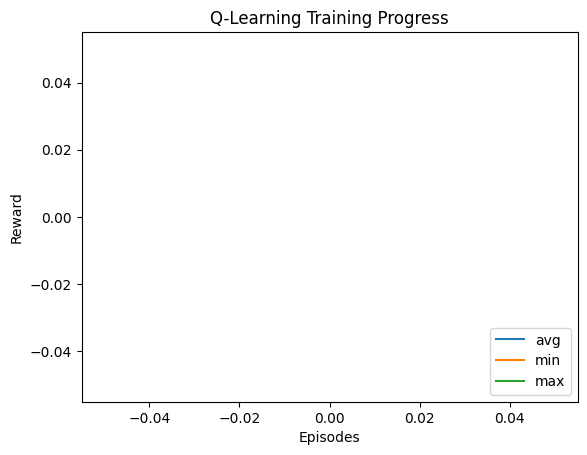

In [35]:
plt.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['avg'], label="avg")
plt.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['min'], label="min")
plt.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['max'], label="max")
plt.legend(loc=4)
plt.title("Q-Learning Training Progress")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.show()

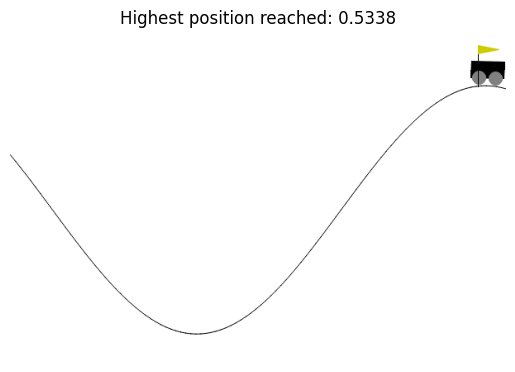

In [36]:
if highest_frame is not None:
    plt.imshow(highest_frame)
    plt.title(f"Highest position reached: {highest_position:.4f}")
    plt.axis('off')
    plt.show()
else:
    print("No frame captured.")



In [37]:
# !pip install gym
# !pip install matplotlib
# !pip install numpy==1.23.5

In [50]:
# import gymnasium as gym # Changed to gymnasium and kept alias for compatibility
# import numpy as np
# import matplotlib.pyplot as plt
# import pickle
# from numpy.linalg import svd

In [51]:
# env = gym.make("MountainCar-v0", render_mode='rgb_array') # Changed to gymnasium.make and added render_mode
# DISCRETE_OS_SIZE = [20] * len(env.observation_space.high)
# discrete_os_win_size = (env.observation_space.high - env.observation_space.low) / DISCRETE_OS_SIZE

In [41]:
LEARNING_RATE = 0.1
DISCOUNT = 0.95
EPISODES = 500
SHOW_EVERY = 10

epsilon = 0.5
START_EPSILON_DECAYING = 1
END_EPSILON_DECAYING = EPISODES // 2
epsilon_decay_value = epsilon / (END_EPSILON_DECAYING - START_EPSILON_DECAYING)

In [42]:
SVD_EVERY = 5
SVD_RANK = 1


In [43]:
ep_rewards = []
aggr_ep_rewards = {'ep': [], 'avg': [], 'min': [], 'max': []}


In [44]:
q_table = np.random.uniform(low=-2, high=0, size=(DISCRETE_OS_SIZE + [env.action_space.n]))

def get_discrete_state(state):
    discrete_state = (state - env.observation_space.low) / discrete_os_win_size
    discrete_state = np.clip(discrete_state, 0, np.array(DISCRETE_OS_SIZE) - 1)
    return tuple(discrete_state.astype(np.int32))

# Track highest position and frame
highest_position = -float('inf')
highest_frame = None


In [53]:
for episode in range(EPISODES):
    episode_reward = 0
    discrete_state = get_discrete_state(env.reset()[0])
    done = False

    while not done:
        # Epsilon-greedy action
        if np.random.random() > epsilon:
            action = np.argmax(q_table[discrete_state])
        else:
            action = np.random.randint(0, env.action_space.n)

        # Changed for gymnasium: unpack 5 values and combine terminated/truncated
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        new_discrete_state = get_discrete_state(new_state)

        # Track highest position and save rendered frame
        if new_state[0] > highest_position:
            highest_position = new_state[0]
            # Changed for gymnasium: render_mode is set during env.make()
            highest_frame = env.render()

        if not done:
            max_future_q = np.max(q_table[new_discrete_state])
            current_q = q_table[discrete_state + (action,)]
            new_q = (1 - LEARNING_RATE) * current_q + LEARNING_RATE * (reward + DISCOUNT * max_future_q)
            q_table[discrete_state + (action,)] = new_q
        # Changed for gymnasium: access goal_position via env.unwrapped
        elif new_state[0] >= env.unwrapped.goal_position:
            q_table[discrete_state + (action,)] = 0

        discrete_state = new_discrete_state
        episode_reward += reward

    # Decay epsilon
    if END_EPSILON_DECAYING >= episode >= START_EPSILON_DECAYING:
        epsilon -= epsilon_decay_value

    ep_rewards.append(episode_reward)

In [60]:
# if episode % SHOW_EVERY == 0:
#         avg_reward = sum(ep_rewards[-SHOW_EVERY:]) / SHOW_EVERY
#         aggr_ep_rewards['ep'].append(episode)
#         aggr_ep_rewards['avg'].append(avg_reward)
#         aggr_ep_rewards['min'].append(min(ep_rewards[-SHOW_EVERY:]))
#         aggr_ep_rewards['max'].append(max(ep_rewards[-SHOW_EVERY:]))
#         print(f"Episode: {episode}, avg: {avg_reward:.2f}, min: {min(ep_rewards[-SHOW_EVERY:])}, max: {max(ep_rewards[-SHOW_EVERY:])}")

#     # 🔧 Apply SVD
#     if episode % SVD_EVERY == 0 and episode != 0:
#         print(f"Applying SVD compression at episode {episode}")
#         for a in range(env.action_space.n):
#             q_slice = q_table[:, :, a]
#             U, S, Vt = svd(q_slice, full_matrices=False)
#             S[SVD_RANK:] = 0  # Keep top-k singular values
#             q_table[:, :, a] = np.dot(U * S, Vt)
#             print("size is")
#             print(q_table.size)

In [61]:
with open("qtable.pkl", "wb") as f:
    pickle.dump(q_table, f)

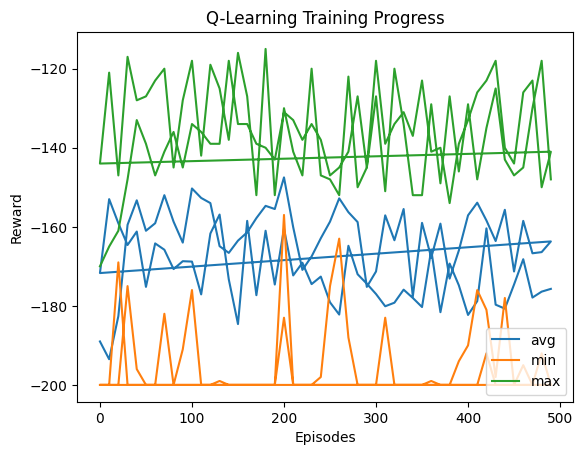

In [62]:
plt.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['avg'], label="avg")
plt.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['min'], label="min")
plt.plot(aggr_ep_rewards['ep'], aggr_ep_rewards['max'], label="max")
plt.legend(loc=4)
plt.title("Q-Learning Training Progress")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.show()

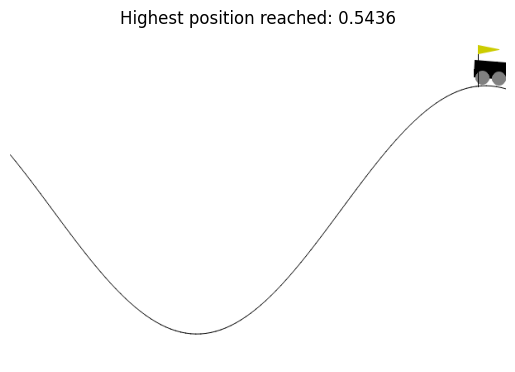

In [63]:
if highest_frame is not None:
    plt.imshow(highest_frame)
    plt.title(f"Highest position reached: {highest_position:.4f}")
    plt.axis('off')
    plt.show()
else:
    print("No frame captured.")